# scikit-learn Workflows with kernellib

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jejjohnson/kernellib/blob/main/docs/notebooks/sklearn_workflows.ipynb)

kernellib's estimators are immutable JAX modules, which is what lets `jax.grad` run straight through `fit`. scikit-learn expects the opposite: mutable objects whose `fit` returns `self`. The optional `kernellib.sklearn` module (`pip install "kernellib[sklearn]"`) bridges the two with thin adapters, so kernellib's kernels, solvers, feature maps and dependence measures plug into `GridSearchCV`, `Pipeline` and `cross_val_score`, and kernel hyperparameters become searchable parameters.

**What you'll learn:**

1. Fitting `KernelRidge` with a median-heuristic default kernel, and tuning a kernel's lengthscale with `GridSearchCV` through nested `kernel__lengthscale` parameters.
2. Scaling up with `FalkonRegressor` and `EigenProRegressor`.
3. Kernel feature maps (random Fourier, FastFood, Nyström) as transformers in a `Pipeline`.
4. Getting the fitted kernellib object back for JAX.
5. Independence and two-sample tests with `HSIC` and `MMD`.

## Setup

In [1]:
import subprocess
import sys


try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "kernellib[sklearn] @ git+https://github.com/jejjohnson/kernellib@main",
        ],
        check=True,
    )

In [2]:
import time
import warnings


warnings.filterwarnings("ignore", message=r".*IProgress.*")

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV, cross_val_score, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

import kernellib as kl
from kernellib.sklearn import (
    HSIC,
    MMD,
    EigenProRegressor,
    FalkonRegressor,
    FastFoodFeatures,
    KernelRidge,
    NystromFeatures,
    RandomFourierFeatures,
)


jax.config.update("jax_enable_x64", True)

In [3]:
import importlib.util


try:
    from IPython import get_ipython

    ipython = get_ipython()
except ImportError:
    ipython = None

if ipython is not None and importlib.util.find_spec("watermark") is not None:
    ipython.run_line_magic("load_ext", "watermark")
    ipython.run_line_magic(
        "watermark",
        "-v -m -p jax,sklearn,matplotlib,kernellib",
    )
else:
    print("watermark extension not installed; skipping reproducibility readout.")

Python implementation: CPython
Python version       : 3.12.11
IPython version      : 9.17.1

jax       : 0.11.2
sklearn   : 1.9.1
matplotlib: 3.11.2
kernellib : 0.0.6

Compiler    : Clang 20.1.4 
OS          : Linux
Release     : 6.18.44-fc-v37
Machine     : x86_64
Processor   : x86_64
CPU cores   : 4
Architecture: 64bit



## Data

A smooth function of two inputs with additive noise. We keep a held-out test set for every model below.

In [4]:
rng = np.random.default_rng(0)


def make_data(n):
    X = rng.uniform(-2.0, 2.0, size=(n, 2))
    f = np.sin(2.0 * X[:, 0]) * np.cos(1.5 * X[:, 1]) + 0.3 * X[:, 1]
    return X, f + 0.1 * rng.normal(size=n)


X, y = make_data(2000)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)
# The noise variance is 0.01, so no model can beat this test R^2 on average.
ceiling = 1.0 - 0.01 / np.var(y_test)
print(f"train {X_train.shape}, test {X_test.shape}, noise-limited R^2 {ceiling:.3f}")

train (1500, 2), test (500, 2), noise-limited R^2 0.970


## Kernel ridge regression

With no kernel, `KernelRidge` uses an RBF kernel whose lengthscale is the median pairwise distance of the training inputs (`kl.estimate_lengthscale`). The fitted kernel is `kernel_`; the `kernel` parameter itself is left as `None`, as scikit-learn requires.

One difference from `sklearn.kernel_ridge.KernelRidge`: `regularization` is scaled by the number of training points, so the system solved is $(K + \lambda n I)\alpha = y$. The same $\lambda$ therefore means the same thing at any $n$, and in `FalkonRegressor` too.

In [5]:
default = KernelRidge().fit(X_train, y_train)
print(f"median-heuristic lengthscale: {float(default.kernel_.lengthscale):.3f}")
print(f"test R^2: {default.score(X_test, y_test):.4f}")

median-heuristic lengthscale: 2.017


test R^2: 0.5356


The heuristic is a starting point, not a tuned model: with the default ridge it is far from the noise limit. The next section tunes it.

## Tuning the kernel with `GridSearchCV`

A kernellib kernel's fields are nested parameters of the estimator: `kernel__lengthscale`, `kernel__variance`, `kernel__nu` for a Matérn, and `kernel__kernels__0__lengthscale` inside a sum. So a grid search over lengthscales needs no custom code.

In [6]:
lengthscales = np.geomspace(0.05, 5.0, 12)
regularizations = [1e-6, 1e-4, 1e-2]
search = GridSearchCV(
    KernelRidge(kernel=kl.Matern(nu=2.5)),
    {"kernel__lengthscale": lengthscales, "regularization": regularizations},
    cv=5,
).fit(X_train, y_train)

best = search.best_params_
print(
    f"best lengthscale {best['kernel__lengthscale']:.3f}, "
    f"regularization {best['regularization']:.0e}"
)
print(f"test R^2: {search.score(X_test, y_test):.4f}")

best lengthscale 3.290, regularization 1e-06


test R^2: 0.9697


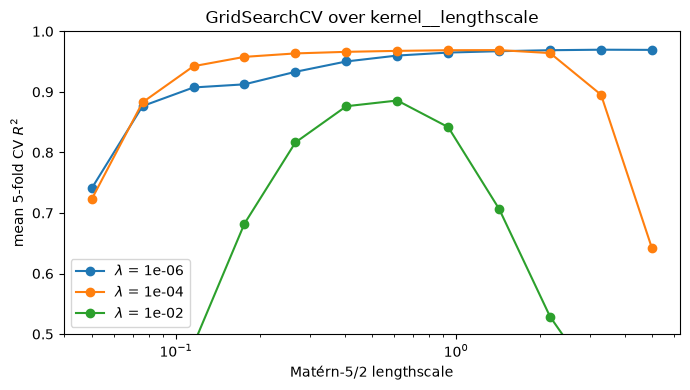

In [7]:
scores = search.cv_results_["mean_test_score"].reshape(
    len(lengthscales), len(regularizations)
)
fig, ax = plt.subplots(figsize=(7, 4))
for j, lam in enumerate(regularizations):
    ax.semilogx(lengthscales, scores[:, j], marker="o", label=rf"$\lambda$ = {lam:.0e}")
ax.set_xlabel("Matérn-5/2 lengthscale")
ax.set_ylabel("mean 5-fold CV $R^2$")
ax.set_ylim(0.5, 1.0)
ax.legend()
ax.set_title("GridSearchCV over kernel__lengthscale")
plt.tight_layout()
plt.show()

The tuned model reaches the noise limit printed above. The curves show why both parameters need searching together. With the heaviest ridge the score peaks at an intermediate lengthscale and stays well below the others. With the lighter ridges it plateaus near the noise limit over a wide range, and only the lightest holds that plateau out to the longest lengthscales, where the heavier ridge over-smooths.

## Scaling up: Falkon and EigenPro

Exact kernel ridge regression costs $O(n^3)$ time and $O(n^2)$ memory. `FalkonRegressor` solves the Nyström system on $m$ centres with a preconditioned conjugate-gradient solve, streaming the $n \times m$ cross kernel ($O(m^2)$ memory). `EigenProRegressor` runs preconditioned stochastic gradient descent on the full interpolation problem, touching one $b \times n$ kernel block at a time. Both are ordinary scikit-learn regressors, and they reuse the kernel `GridSearchCV` just found.

In [8]:
X_big, y_big = make_data(20_000)
X_big_train, X_big_test, y_big_train, y_big_test = train_test_split(
    X_big, y_big, random_state=0
)
kernel = search.best_estimator_.kernel

models = {
    "FalkonRegressor (m=500)": FalkonRegressor(
        kernel, n_inducing=500, regularization=1e-6, random_state=0
    ),
    "EigenProRegressor": EigenProRegressor(
        kernel,
        epochs=3,
        batch_size=512,
        subsample_size=2000,
        n_components=100,
        random_state=0,
    ),
}
for name, model in models.items():
    start = time.perf_counter()
    model.fit(X_big_train, y_big_train)
    elapsed = time.perf_counter() - start
    r2 = model.score(X_big_test, y_big_test)
    print(f"{name:26s} n = {len(X_big_train)}  fit {elapsed:5.1f} s  test R^2 {r2:.4f}")

FalkonRegressor (m=500)    n = 15000  fit   5.4 s  test R^2 0.9705


EigenProRegressor          n = 15000  fit   5.9 s  test R^2 0.9691


Both reach roughly the noise-limited accuracy of the tuned exact model, on ten times as much training data.

## Feature maps in a `Pipeline`

Every kernellib feature map is also a transformer, like scikit-learn's `RBFSampler` and `Nystroem`, but for any kernel with a spectral sampler (random Fourier, orthogonal, FastFood) or any kernel at all (Nyström), with ARD lengthscales. Followed by a linear model, a feature map gives an approximate kernel method in $O(nR)$.

In [9]:
transformers = {
    "RandomFourierFeatures": RandomFourierFeatures(
        500, kernel=kl.Matern(nu=2.5), random_state=0
    ),
    "FastFoodFeatures": FastFoodFeatures(500, kernel=kl.Matern(nu=2.5), random_state=0),
    "NystromFeatures": NystromFeatures(500, kernel=kl.Matern(nu=2.5), random_state=0),
}
for name, transformer in transformers.items():
    pipe = make_pipeline(StandardScaler(), transformer, Ridge(alpha=1e-3))
    cv = cross_val_score(pipe, X_train, y_train, cv=5)
    print(f"{name:22s} CV R^2 {cv.mean():.4f} ± {cv.std():.4f}")

RandomFourierFeatures  CV R^2 0.9694 ± 0.0028


FastFoodFeatures       CV R^2 0.9693 ± 0.0030


NystromFeatures        CV R^2 0.9663 ± 0.0036


Feature names follow scikit-learn's conventions, so pandas output and column selection work as for any transformer:

In [10]:
fitted = transformers["NystromFeatures"].fit(X_train)
print(fitted.get_feature_names_out()[:4])

['nystromfeatures0' 'nystromfeatures1' 'nystromfeatures2'
 'nystromfeatures3']


## Back to JAX

The adapters keep the fitted kernellib object: `model_` for regressors, `feature_map_` for transformers. It is a JAX PyTree, so everything kernellib offers still works on it. Here we differentiate a validation loss with respect to the lengthscale of the best `GridSearchCV` model, refitting inside the function:

In [11]:
best_model = search.best_estimator_.model_  # a fitted kl.KRR
print(type(best_model).__name__, best_model.alpha.shape)

X_val, y_val = jnp.asarray(X_test), jnp.asarray(y_test)


def validation_loss(log_ell):
    k = kl.Matern(nu=2.5, lengthscale=jnp.exp(log_ell))
    model = kl.KRR(k, regularization=best["regularization"])
    return model.fit(jnp.asarray(X_train), jnp.asarray(y_train)).loss(X_val, y_val)


log_ell = jnp.log(best["kernel__lengthscale"])
grad = jax.grad(validation_loss)(log_ell)
print(f"d loss / d log(lengthscale) at the grid optimum: {grad:.2e}")

KRR (1500,)


d loss / d log(lengthscale) at the grid optimum: 1.55e-04


## Dependence: `HSIC` and `MMD`

`HSIC` and `MMD` follow the same conventions (constructor parameters, `fit` returning `self`, trailing-underscore results, `clone`) without being predictors. `fit` estimates any missing kernel bandwidth by the median heuristic, computes the statistic, and, with `n_permutations > 0`, an exact permutation p-value.

First, independence. $y = x^2$ is only weakly correlated with $x$ (zero in expectation for symmetric $x$) but is completely dependent on it:

In [12]:
x = rng.normal(size=(200, 1))
cases = {
    "y = x^2 + noise": x**2 + 0.1 * rng.normal(size=(200, 1)),
    "y independent of x": rng.normal(size=(200, 1)),
}
for name, target in cases.items():
    corr = np.corrcoef(x[:, 0], target[:, 0])[0, 1]
    test = HSIC(n_permutations=499, random_state=0).fit(x, target)
    print(
        f"{name:20s} corr {corr:+.3f}  HSIC {test.statistic_:.4f}  "
        f"p = {test.p_value_:.3f}"
    )

y = x^2 + noise      corr +0.163  HSIC 0.0351  p = 0.002


y independent of x   corr +0.029  HSIC 0.0010  p = 0.358


The dependence is detected even though the linear correlation is weak.

Then two samples. `MMD` compares samples from $\mathcal{N}(0, I)$ and $\mathcal{N}(\delta \mathbf{1}, I)$. A single test at one shift is noisy, so we estimate the test's power instead: for each shift, the fraction of 20 independent pairs of samples on which the permutation test rejects at the 5% level. At $\delta = 0$ that fraction is the false-positive rate, which an exact test keeps near 5%.

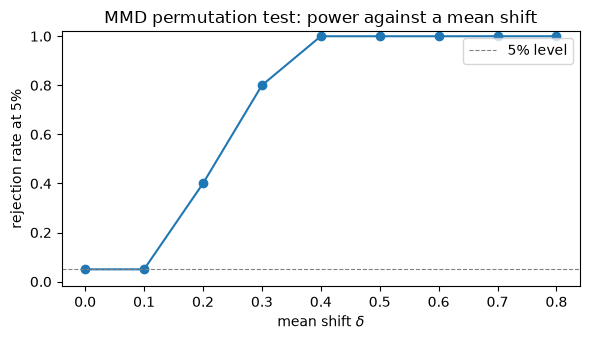

In [13]:
shifts = np.linspace(0.0, 0.8, 9)
n_repeats = 20
rejection_rate = []
for delta in shifts:
    rejections = 0
    for _ in range(n_repeats):
        A = rng.normal(size=(100, 2))
        B = rng.normal(size=(100, 2)) + delta
        test = MMD(estimator="unbiased", n_permutations=99, random_state=0).fit(A, B)
        rejections += test.p_value_ <= 0.05
    rejection_rate.append(rejections / n_repeats)

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(shifts, rejection_rate, marker="o")
ax.axhline(0.05, color="grey", ls="--", lw=0.8, label="5% level")
ax.set_xlabel(r"mean shift $\delta$")
ax.set_ylabel("rejection rate at 5%")
ax.set_ylim(-0.02, 1.02)
ax.legend()
ax.set_title("MMD permutation test: power against a mean shift")
plt.tight_layout()
plt.show()

With no shift the test rejects on 1 of the 20 pairs, the 5% it is designed for; by $\delta = 0.4$, less than half a standard deviation per coordinate, it rejects on every pair.

## Summary

- `kernellib.sklearn` is opt-in: `import kernellib` never loads scikit-learn.
- Regressors (`KernelRidge`, `FalkonRegressor`, `EigenProRegressor`) and transformers (every feature map) pass scikit-learn's `check_estimator` suite.
- Kernel hyperparameters are nested parameters (`kernel__lengthscale`), so the model-selection tools search over them directly.
- The fitted kernellib object (`model_`, `feature_map_`) is still a JAX PyTree for gradients and transforms.
- `HSIC` and `MMD` give statistics and permutation p-values with scikit-learn-style ergonomics.